In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Unproject LUT (LookUp Table) example

The function which goes from pixel location to 3D ray is called
`unproject()`. It is usually not possible to compute in closed form,
so it must be iteratively approximated. Unfortunately, this process
is slow, which can be a problem for some applications.

Lensboy allows you to precompute these values once ahead of time,
for fast lookup during operation. The runtime LUT stays compact and
fast, while the accuracy analysis is available separately on demand.

This notebook builds a `.unproject_LUT` file from the bundled OpenCV test
calibration, saves it to `examples/generated/`, reloads it, and compares the
cached rays against the exact camera model.

The controls intentionally stay in a moderate range so the notebook remains
interactive. If you want a denser cache, edit the values in the cells below.

In [76]:
from pathlib import Path

import numpy as np

import lensboy as lb
from lensboy.analysis import compute_lut_error_heatmap

In [77]:
repo_root = Path(".").resolve().parent
data_dir = repo_root / "data" / "test_datasets"
output_dir = repo_root / "examples" / "generated"
output_dir.mkdir(parents=True, exist_ok=True)

## Source camera model

Using an OpenCV calibration that comes with Lensboy for example purposes.

In [99]:
model = lb.PinholeSplined.load(data_dir / "spline.json")
# model = lb.OpenCV.load(data_dir / "opencv.json")
model

PinholeSplined(3088x2064, f=[1355.8, 1355.7], c=[1513.5, 1078.6], knots=30x20, fov=[143.5°, 127.6°])

## Compute the lookup table

Edit the variables below to control how the LUT is created and used.

In [100]:
pixel_stride = None

In [101]:
lut = model.get_unproject_lut(
    pixel_stride=pixel_stride,
)

## Save the lookup-table to disk

In [93]:
lut_filename = (
    f"spline_stride_{int(pixel_stride) if pixel_stride is not None else 'full'}.lut"
)
lut_dir = output_dir / lut_filename
lut.save(lut_dir)
print(f"Saved to {lut_dir.relative_to(repo_root)}")

Saved to examples/generated/spline_stride_full.lut


## Load the lookup-table from disk

In [88]:
loaded = lb.UnprojectLUT.load(lut_dir)

print(f"Grid size: {loaded.grid_width} x {loaded.grid_height}")

Grid size: 773 x 517


In [89]:
interpolation_mode = "bilinear"  # "nearest", "bilinear", or "bicubic"

## Error heatmap

Per-cell maximum angular error for the chosen interpolation mode in milli degrees.

The cyan arrows show the direction of the local peak x/y
interpolation error within each sampled cell.

Computed heatmap in 0.18 seconds


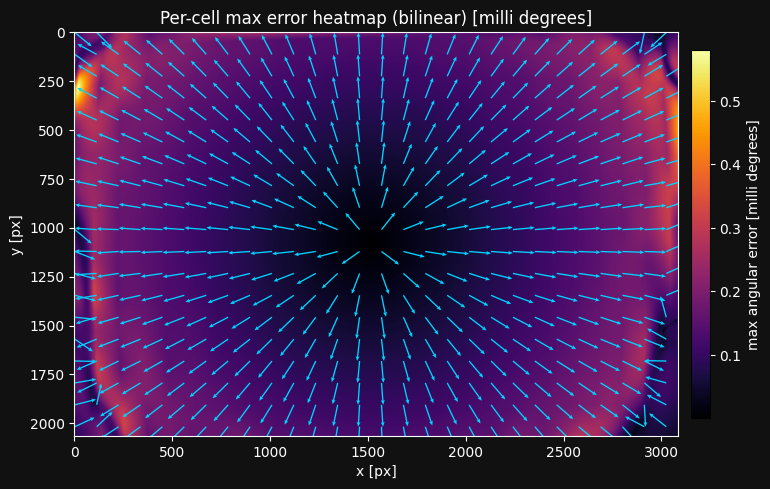

Loaded and plotted heatmap in 0.18 seconds


In [90]:
from timeit import default_timer
heatmap_filename = (
    f"spline_stride_{int(pixel_stride)}"
    f"_{interpolation_mode}_error_heatmap.npz"
)
heatmap_path = output_dir / heatmap_filename

start_time = default_timer()
heatmap = compute_lut_error_heatmap(
    loaded, model, interpolation=interpolation_mode,
)
end_time = default_timer()
print(f"Computed heatmap in {end_time - start_time:.2f} seconds")

# start_time = default_timer()
# heatmap.save(heatmap_path)
# end_time = default_timer()
# print(f"Saved heatmap in {end_time - start_time:.2f} seconds")


# start_time = default_timer()
# loaded_heatmap = UnprojectLUTErrorHeatmap.load(heatmap_path)
# end_time = default_timer()
# print(f"Loaded heatmap in {end_time - start_time:.2f} seconds")

start_time = default_timer()
heatmap.plot(
    angular_unit="mdeg",
    figsize=(7.8, 5.3),
    arrow_scale=1.0,
    # vmax=1.0,
    constant_arrow_length=True

)
end_time = default_timer()
print(f"Loaded and plotted heatmap in {end_time - start_time:.2f} seconds")

## C++ runtime

The same file can be loaded from the standalone runtime in
`cpp_runtime/`. Simply copy-paste those files into your project
and use them like so:

```cpp
#include "unproject_lut.hpp"

auto lut = lensboy::UnprojectLUT::load("camera_runtime.unproject_LUT");
auto result = lut.query(
    1280.0,
    720.0,
    lensboy::InterpolationMode::kBilinear,
    lensboy::BoundsMode::kStrict
);

if (result.valid) {
    do_stuff(result.ray);
}
```